# Homework 04: Building CNNs for Image Classification

### Due: September 27th at 11:59pm (with 2-hour + 1 minute grace period) and worth 85 points

In this assignment, you will take your first steps into designing and training convolutional neural networks (CNNs) for image classification. Starting from a simple baseline, you will experiment with modifications that reflect the kinds of design choices practitioners face every day. Along the way, you’ll see how architecture, hyperparameters, normalization, pooling strategies, and learning rate schedules can each shape a model’s performance.

The problems are organized to build on each other:

1. **Hyperparameters:** Begin with a baseline CNN and try variations in learning rate, layer width, depth, and dropout.
2. **Batch Normalization:** Add normalization after convolutional layers to stabilize training and speed convergence.
3. **Global Average Pooling:** Replace the flatten-and-dense head with a modern pooling layer, reducing parameters and improving generalization.
4. **ReduceLROnPlateau:** Explore a widely used learning rate scheduler that adapts when validation progress slows.
5. **Very Deep CNN:** Finally, run a VGG-16–style model to observe how deeper networks behave compared to smaller ones.

By the end of this homework, you will have hands-on experience with both classical and modern CNN design strategies, a sense of how different components affect learning, and a toolkit of techniques that will serve you in future image processing projects. 

There are 10 graded questions, worth 8 points each, with 5 points free if you complete all of the graded questions in the homework. 


## 1. Setup and Data Loading


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import os,time,random,kagglehub

import tensorflow as tf
from tensorflow.keras import layers, Input, models, callbacks, regularizers,initializers
from tensorflow.keras.callbacks import Callback,EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical, load_img, img_to_array
from tensorflow.keras.optimizers import Adam,AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay, ExponentialDecay
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img, img_to_array
from tensorflow.keras.layers import Dense,Input,Dropout,Flatten,MaxPooling2D,Conv2D,SeparableConv2D,GlobalAveragePooling2D,GlobalMaxPooling2D,BatchNormalization

from sklearn.model_selection import train_test_split

# utility code

# -------------------------
# Reproducibility settings
# -------------------------

random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppresses INFO and WARNING messages

/home/caleb/miniconda3/envs/tf_gpu/lib/python3.12/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
I0000 00:00:1790114796.323712    3171 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790114796.655095    3171 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790114797.870876    3171 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different compu

### Utility function to plot learning curves and keep track of all results

- Call `print_results()` to see listing of all results logged so far

In [2]:

def plot_learning_curves(hist, title, verbose=True):
    
    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    if verbose:
        print(f"Final Training Loss:            {hist.history['loss'][-1]:.4f}")
        print(f"Final Training Accuracy:        {hist.history['accuracy'][-1]:.4f}")
        print(f"Final Validation Loss:          {hist.history['val_loss'][-1]:.4f}")
        print(f"Final Validation Accuracy:      {hist.history['val_accuracy'][-1]:.4f}")
        print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
        print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)

results = {}

def print_results():
    for title, (acc, ep) in sorted(results.items(), 
                                   key=lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse=True
                                  ):
        print(f"{title:<40}\t{acc:.4f}\t{ep}")

###  Wrapper for training and testing

#### Assumptions:   
- Early stopping is default, add other callbacks as needed
- Testing and training sets already defined, accessed here as global variables

In [3]:
# Uses globals: train_ds, val_ds, test_ds

def train_and_test(model, 
                   epochs        = 500,
                   lr_schedule   = 1e-3,
                   optimizer     = "Adam",
                   title         = "Learning Curves",
                   use_early_stopping = True,
                   patience      = 10,
                   min_delta     = 0.0001,
                   callbacks     = [],
                   verbose       = 0,
                   return_history = False
                  ):

    print(f"\n{title}\n")

    # Choose optimizer
    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule)
    else:
        opt = optimizer

    # Compile
    model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        min_delta=min_delta,
        restore_best_weights=True,
        verbose=verbose
    )

    cbs = ([early_stop] if use_early_stopping else []) + callbacks

    start = time.time()

    # Fit on tf.data datasets (already batched)
    history = model.fit(
        train_ds,
        epochs=epochs,
        validation_data=val_ds,
        callbacks=cbs,
        verbose=verbose
    )

    # Determine best validation accuracy
    if use_early_stopping and hasattr(early_stop, "best_epoch") and early_stop.best_epoch is not None:
        best_epoch = early_stop.best_epoch
        best_acc   = history.history['val_accuracy'][best_epoch]
    else:
        best_epoch = int(np.argmax(history.history['val_accuracy']))
        best_acc   = history.history['val_accuracy'][best_epoch]

    plot_learning_curves(history, title=title)

    # Evaluate on tf.data test set
    test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"\nValidation-Test Gap (accuracy): {abs(best_acc - test_accuracy):.6f}")

    end = time.time()
    print(f"\nExecution Time: " + format_hms(end-start))

    if return_history:
        return history


### Load the Intel Image Classification Dataset  



In [4]:
path      = kagglehub.dataset_download("puneet6060/intel-image-classification")
train_dir = os.path.join(path, "seg_train/seg_train")
test_dir  = os.path.join(path, "seg_test/seg_test")

In [5]:
import os
import numpy as np
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE

def list_files_and_labels(directory, class_names=None, exts=(".jpg", ".jpeg", ".png")):
    """
    Returns:
      filepaths: np.array[str]
      labels:    np.array[int32]
      class_names_used: list[str] in deterministic order
    """
    if class_names is None:
        class_names = sorted(
            d for d in os.listdir(directory)
            if os.path.isdir(os.path.join(directory, d))
        )
    else:
        # keep only classes that exist in this directory, preserve given order
        class_names = [c for c in class_names if os.path.isdir(os.path.join(directory, c))]

    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    filepaths = []
    labels = []

    for cname in class_names:
        folder = os.path.join(directory, cname)
        for fname in sorted(os.listdir(folder)):  # deterministic within class
            if fname.lower().endswith(exts):
                filepaths.append(os.path.join(folder, fname))
                labels.append(class_to_idx[cname])

    return np.array(filepaths), np.array(labels, dtype=np.int32), class_names


def stratified_split_indices(y, val_frac=0.2, seed=42):
    """
    Deterministic stratified split over indices.
    Returns: train_idx, val_idx (np arrays)
    """
    rng = np.random.default_rng(seed)
    y = np.asarray(y)
    n = len(y)

    train_idx_list = []
    val_idx_list = []

    classes = np.unique(y)
    for c in classes:
        idx = np.flatnonzero(y == c)
        rng.shuffle(idx)
        n_val = int(np.floor(len(idx) * val_frac))
        val_idx_list.append(idx[:n_val])
        train_idx_list.append(idx[n_val:])

    train_idx = np.concatenate(train_idx_list)
    val_idx = np.concatenate(val_idx_list)

    # Optional: shuffle each split deterministically so batches mix classes
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)

    return train_idx, val_idx


def make_image_dataset(filepaths, labels, img_size=(150, 150), batch_size=32,
                       shuffle=False, seed=42, cache_to_disk=None):
    """
    Builds a tf.data.Dataset that loads images lazily from disk.
    - filepaths: np array of strings
    - labels:    np array of int32
    """
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if shuffle:
        # shuffle file *references* (cheap), not image tensors
        ds = ds.shuffle(buffer_size=len(filepaths), seed=seed, reshuffle_each_iteration=True)

    def _load_and_preprocess(path, label):
        # read bytes -> decode -> resize -> float32 in [0,1]
        img_bytes = tf.io.read_file(path)
        img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
        img = tf.image.resize(img, img_size, method="bilinear")
        img = tf.cast(img, tf.float32) / 255.0
        return img, label

    ds = ds.map(_load_and_preprocess, num_parallel_calls=AUTOTUNE)

    if cache_to_disk is not None:
        # Disk caching avoids RAM blowups; /tmp is fine in Colab
        ds = ds.cache(cache_to_disk)

    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


# -------------------------
# Example usage for Intel dataset
# -------------------------

IMG_SIZE    = (150, 150)
INPUT_SHAPE = IMG_SIZE + (3,)
BATCH_SIZE  = 32
VAL_FRAC    = 0.2
SEED        = random_seed  # use your existing seed

# 1) List train files/labels deterministically
train_files, train_labels, class_names = list_files_and_labels(train_dir)

num_classes = len(class_names)

# 2) Stratified deterministic split of *indices* (no images loaded)
train_idx, val_idx = stratified_split_indices(train_labels, val_frac=VAL_FRAC, seed=SEED)

# 3) Slice file lists
files_train = train_files[train_idx]
y_train     = train_labels[train_idx]
files_val   = train_files[val_idx]
y_val       = train_labels[val_idx]

# 4) Build datasets (lazy image loading)
train_ds = make_image_dataset(files_train, y_train, img_size=IMG_SIZE,
                              batch_size=BATCH_SIZE, shuffle=True, seed=SEED,
                              cache_to_disk=None)  

val_ds   = make_image_dataset(files_val, y_val, img_size=IMG_SIZE,
                              batch_size=BATCH_SIZE, shuffle=False,
                              cache_to_disk=None)  

# 5) Test set: keep same class mapping as train
test_files, test_labels, _ = list_files_and_labels(test_dir, class_names=class_names)
test_ds = make_image_dataset(test_files, test_labels, img_size=IMG_SIZE,
                             batch_size=BATCH_SIZE, shuffle=False,
                             cache_to_disk=None)




I0000 00:00:1790114800.140521    3171 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5527 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9


### Examine The Dataset

In [6]:

def show_counts_from_labels(name, labels, class_names):
    c = Counter(labels.tolist())
    counts = {class_names[k]: c.get(k, 0) for k in range(len(class_names))}
    print(f"{name} per-class counts:", counts)

print("class_names:", class_names)
print("train examples:", len(files_train), "val examples:", len(files_val), "test examples:", len(test_files))

show_counts_from_labels("train", y_train, class_names)
show_counts_from_labels("val",   y_val,   class_names)
show_counts_from_labels("test",  test_labels, class_names)


class_names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
train examples: 11230 val examples: 2804 test examples: 3000
train per-class counts: {'buildings': 1753, 'forest': 1817, 'glacier': 1924, 'mountain': 2010, 'sea': 1820, 'street': 1906}
val per-class counts: {'buildings': 438, 'forest': 454, 'glacier': 480, 'mountain': 502, 'sea': 454, 'street': 476}
test per-class counts: {'buildings': 437, 'forest': 474, 'glacier': 553, 'mountain': 525, 'sea': 510, 'street': 501}


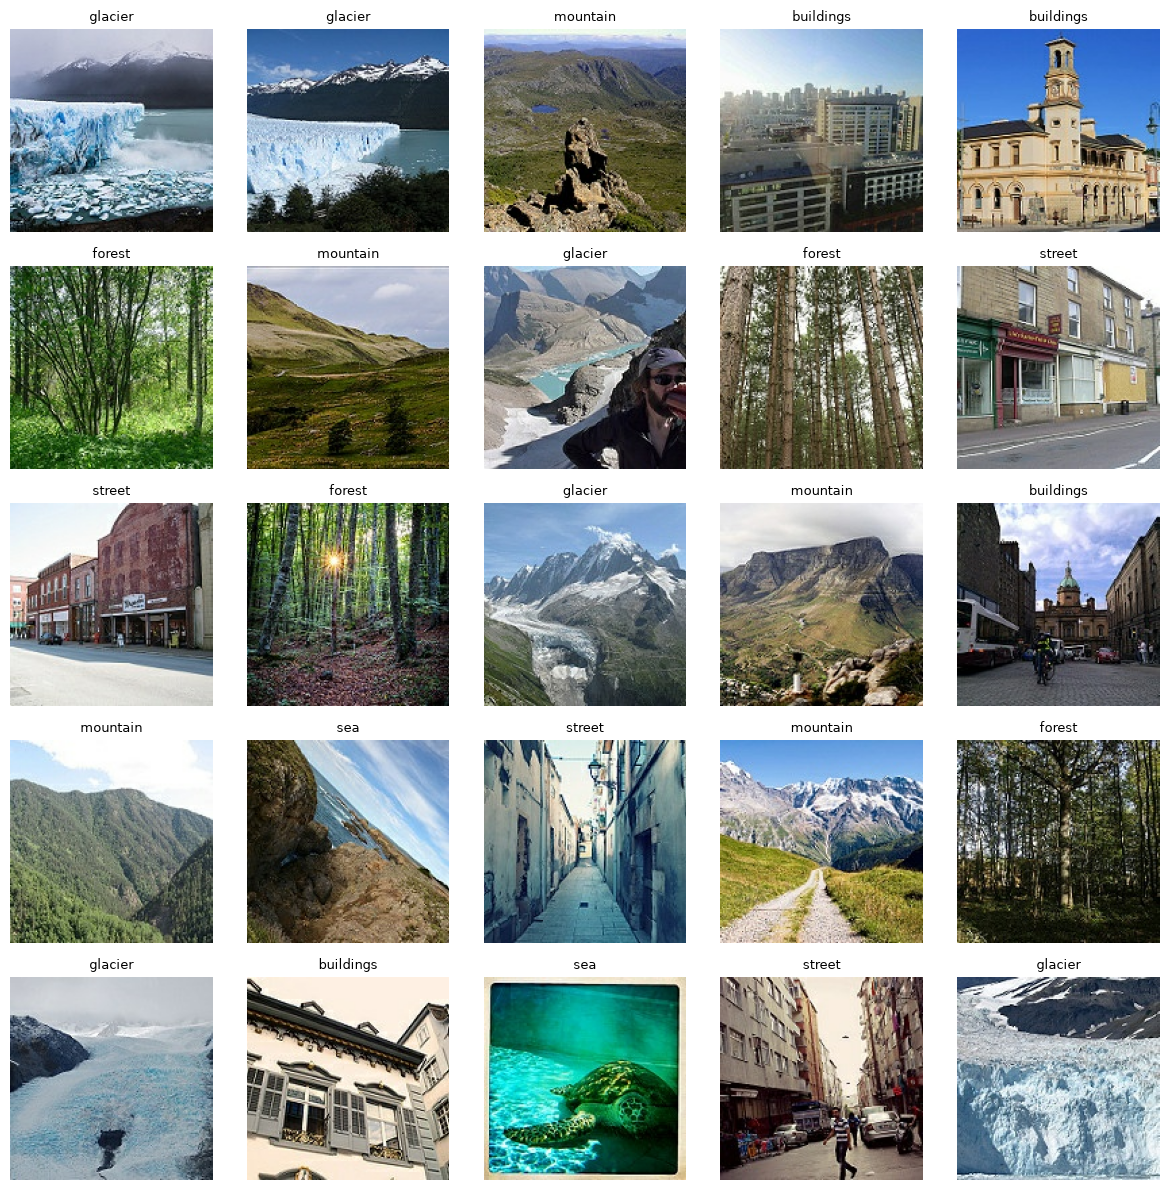

In [7]:
# Show 25 sample images

plt.figure(figsize=(12, 12))

# Take one batch from the dataset
images, labels = next(iter(train_ds))

for i in range(25):
    ax = plt.subplot(5, 5, i + 1)
    plt.imshow(images[i].numpy())
    plt.title(class_names[int(labels[i])], fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()


### Prelude: Baseline CNN (reference model)

This is our **reference** network: two Conv→Pool blocks with channels **32 → 64**, followed by a **single hidden head** `Dense(64)`. We use **He** initialization for ReLU activations and include an **optional `Dropout(0.5)`** to illustrate regularization—comment it out to gauge its impact (ha, not really optional!). 

Use this model as a stable yardstick while you run **ablations**: change **one knob at a time** (e.g., widen/deepen the conv blocks, adjust dropout rate, add batch norm, tweak the LR schedule) and compare results back to this baseline. Focus on **training vs. validation curves**, the **generalization gap**, and how dropout affects **val loss/accuracy** and how long it takes for Early Stopping to kick in. 


> **Note:** On rare runs, training may become numerically unstable and produce `NaN` loss values. If this occurs, rerun the model. If the problem persists, restart the runtime and run the notebook again from the beginning.


Baseline Model



/home/caleb/miniconda3/envs/tf_gpu/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1790114802.902599    3529 service.cc:153] XLA service 0x7f1ed00322f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790114802.902703    3529 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Ti, Compute Capability 8.9 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.26.0)
I0000 00:00:1790114802.927045    3529 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1790114803.030321    3529 cuda_dnn.cc:461] Loaded cuDNN version 92600
I0000 00:00:1790114803.054791    3529 dot_merger.cc:481]

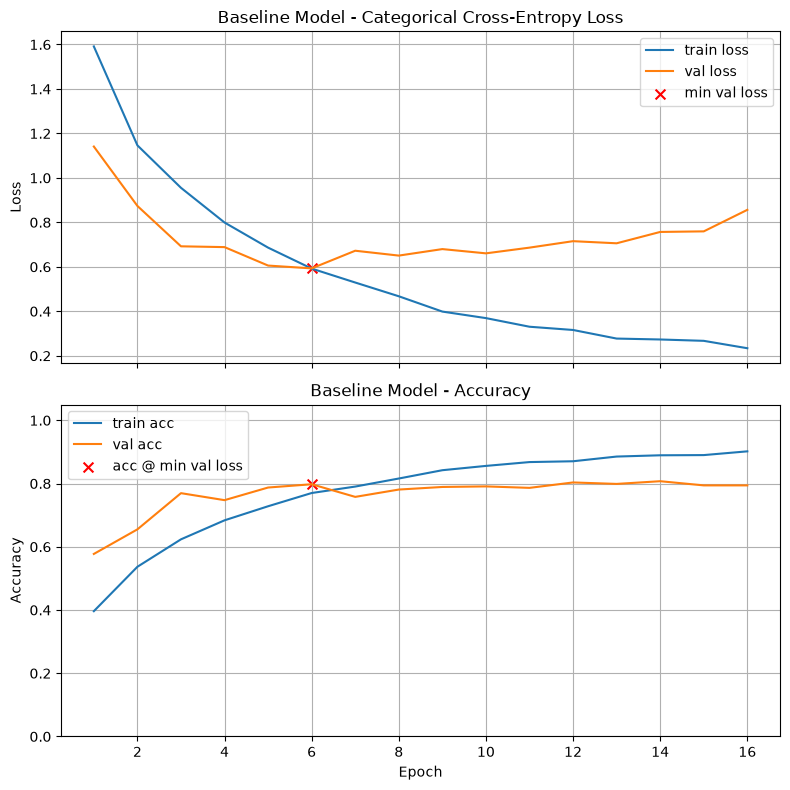

Final Training Loss:            0.2340
Final Training Accuracy:        0.9019
Final Validation Loss:          0.8564
Final Validation Accuracy:      0.7942
Minimum Validation Loss:        0.5931 (Epoch 6)
Validation Accuracy @ Min Loss: 0.7978

Test Loss: 0.6108
Test Accuracy: 0.7990

Validation-Test Gap (accuracy): 0.001211

Execution Time: 00:01:42


In [8]:
he = initializers.HeNormal()                                # best initializer for relu

model_baseline= models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu",kernel_initializer=he),            
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_baseline,title=f"Baseline Model")


## Problem One: Exploring Basic Hyperparameters

**Task:**
Copy the baseline CNN model into the next cell and experiment with basic hyperparameter changes. Your goal is to see whether small tweaks can improve validation accuracy (and hopefully speed up convergence or produce smoother training curves). You must **pick 3 of the following tweaks** and investigate their effect:

**Tweaks to Try:**

1. Adjust the learning rate (default for Adam is `1e-3`).
2. Change the width of the `Conv2D` layers (e.g., 64 → 128).
3. Add an extra `Conv2D` layer (e.g., stack 32 → 64 → 128).
4. Change the width of the `Dense(64 ...)` layer. 
5. Add L2 regularization to the `Dense(64 ...)` layer (see the head of the network in Problem 5 for inspiration).  
6. Modify the dropout rate.
   
Observe the effect of each of your 3 choices in isolation and answer the graded questions.

**Optional:**
Combine two or more changes to see if they work together to improve results (example: try L2 regularization and reduced dropout in the head, as in Problem 5). 


**Pro Tip:** Give each experiment a descriptive title, such as "Problem 1 -- Tweak 1 -- lr: 0.0005" to keep track of your experiments (see last cell in the notebook).

### Problem 1

#### Tweak 1 -- lr: 5e-4 (0.0005)


Baseline Model - lr 5e-4



I0000 00:00:1790114905.169934    3529 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_32796__.31
I0000 00:00:1790114911.928120    3531 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_32796__.31


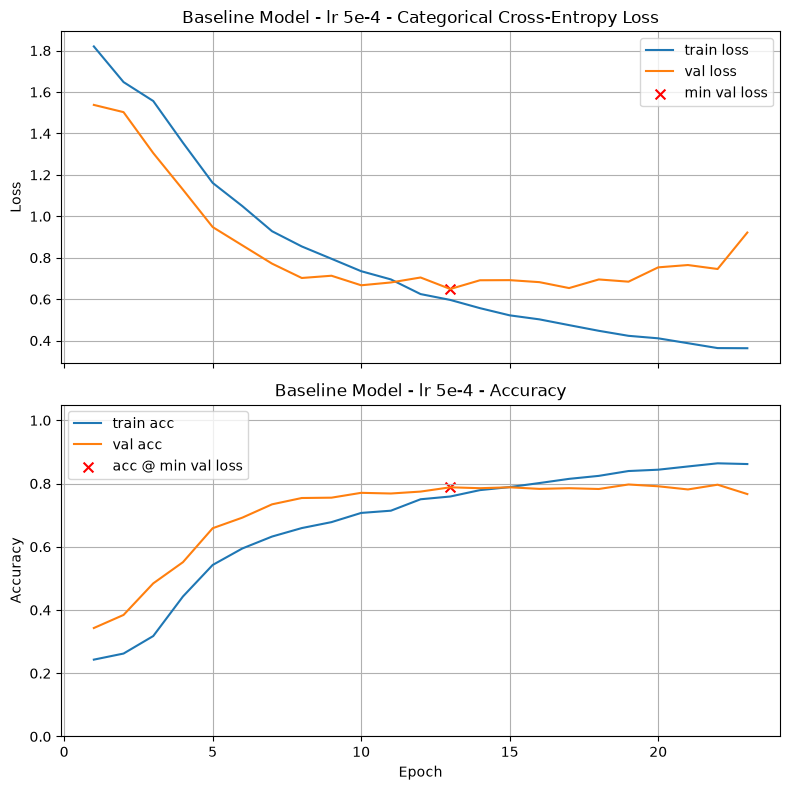

Final Training Loss:            0.3632
Final Training Accuracy:        0.8617
Final Validation Loss:          0.9217
Final Validation Accuracy:      0.7668
Minimum Validation Loss:        0.6492 (Epoch 13)
Validation Accuracy @ Min Loss: 0.7882

Test Loss: 0.7139
Test Accuracy: 0.7740

Validation-Test Gap (accuracy): 0.014160

Execution Time: 00:02:23


In [9]:
he = initializers.HeNormal()                                # best initializer for relu

model_baseline= models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu",kernel_initializer=he),            
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_baseline,title=f"Baseline Model - lr 5e-4", lr_schedule=5e-4)


#### Tweak 2 -- lr: 1e-4


Baseline Model - lr 1e-4



I0000 00:00:1790115048.928373    3531 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_76242__.31
I0000 00:00:1790115055.917824    3531 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_76242__.31


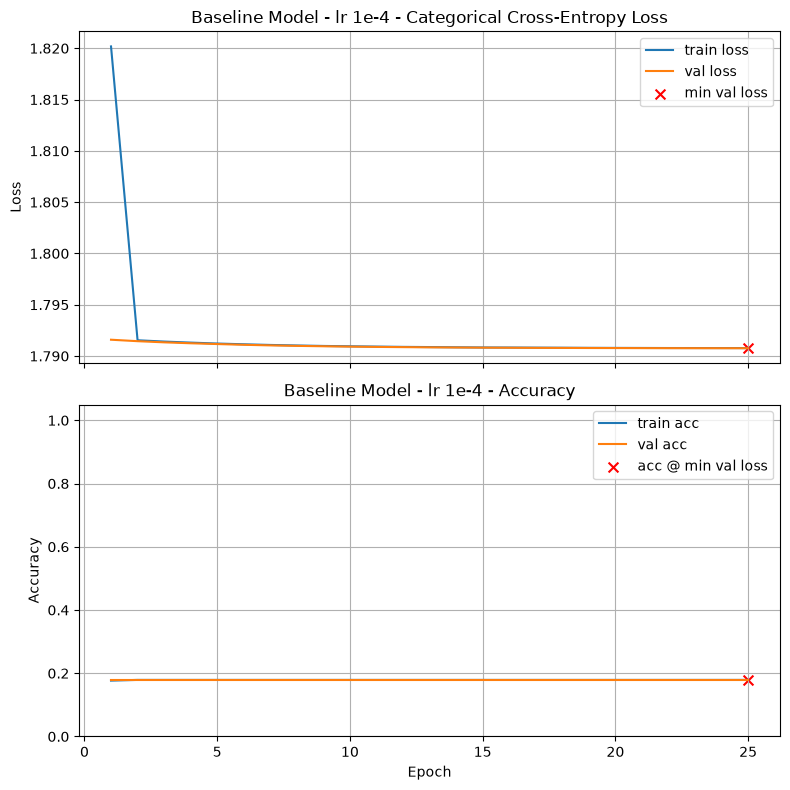

Final Training Loss:            1.7908
Final Training Accuracy:        0.1790
Final Validation Loss:          1.7908
Final Validation Accuracy:      0.1790
Minimum Validation Loss:        1.7908 (Epoch 25)
Validation Accuracy @ Min Loss: 0.1790

Test Loss: 1.7904
Test Accuracy: 0.1750

Validation-Test Gap (accuracy): 0.004030

Execution Time: 00:02:32


In [10]:
he = initializers.HeNormal()                                # best initializer for relu

model_baseline= models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu",kernel_initializer=he),            
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_baseline,title=f"Baseline Model - lr 1e-4", lr_schedule=1e-4)


### Problem 2

### Tweak 1 -- Double Conv2D width (64 and 128)


Baseline Model - double Conv2D width (64 and 128)



I0000 00:00:1790115201.072373    3529 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_123216__.31
I0000 00:00:1790115215.953751    3532 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_123216__.31


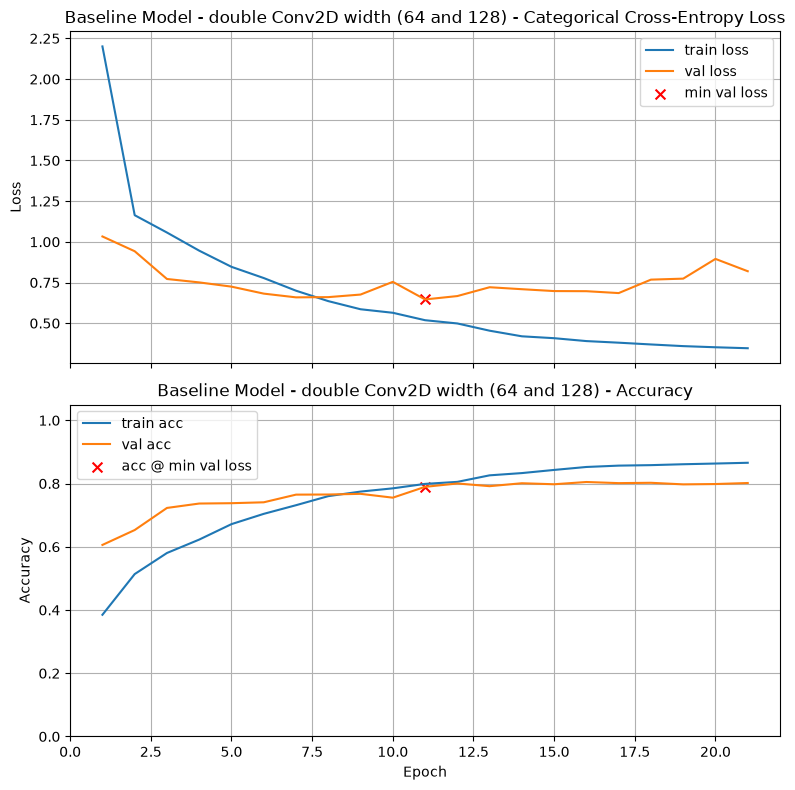

Final Training Loss:            0.3462
Final Training Accuracy:        0.8657
Final Validation Loss:          0.8194
Final Validation Accuracy:      0.8017
Minimum Validation Loss:        0.6460 (Epoch 11)
Validation Accuracy @ Min Loss: 0.7896

Test Loss: 0.7253
Test Accuracy: 0.7713

Validation-Test Gap (accuracy): 0.018253

Execution Time: 00:04:18


In [11]:
he = initializers.HeNormal()                                # best initializer for relu

model_baseline= models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu",kernel_initializer=he),            
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_baseline,title=f"Baseline Model - double Conv2D width (64 and 128)")


### Tweak 2 -- Halve Conv2D width (16 and 32)


Baseline Model - Halve Conv2D width (16 and 32)



I0000 00:00:1790115459.302562    3531 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_163062__.31
I0000 00:00:1790115465.008425    3531 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_163062__.31


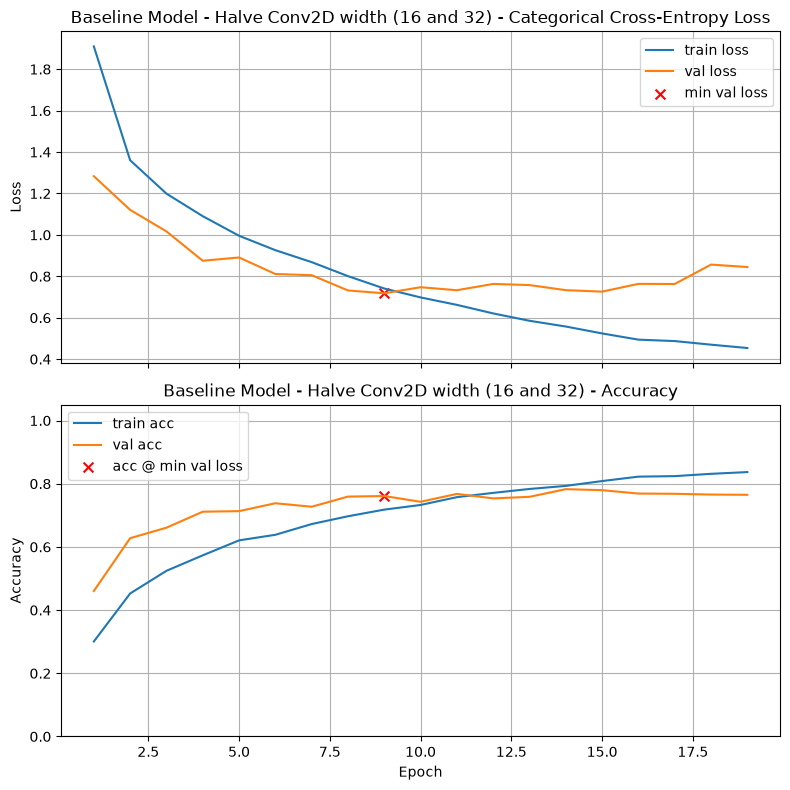

Final Training Loss:            0.4539
Final Training Accuracy:        0.8369
Final Validation Loss:          0.8449
Final Validation Accuracy:      0.7650
Minimum Validation Loss:        0.7180 (Epoch 9)
Validation Accuracy @ Min Loss: 0.7611

Test Loss: 0.7559
Test Accuracy: 0.7467

Validation-Test Gap (accuracy): 0.014389

Execution Time: 00:01:07


In [12]:
he = initializers.HeNormal()                                # best initializer for relu

model_baseline= models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(16, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu",kernel_initializer=he),            
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_baseline,title=f"Baseline Model - Halve Conv2D width (16 and 32)")


### Problem 3

#### Tweak 1 -- Add an extra layer (128)


Baseline Model - Extra 128 Conv2D layer



I0000 00:00:1790115527.139099    3529 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_199657__.40
I0000 00:00:1790115535.644060    3531 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_199657__.40


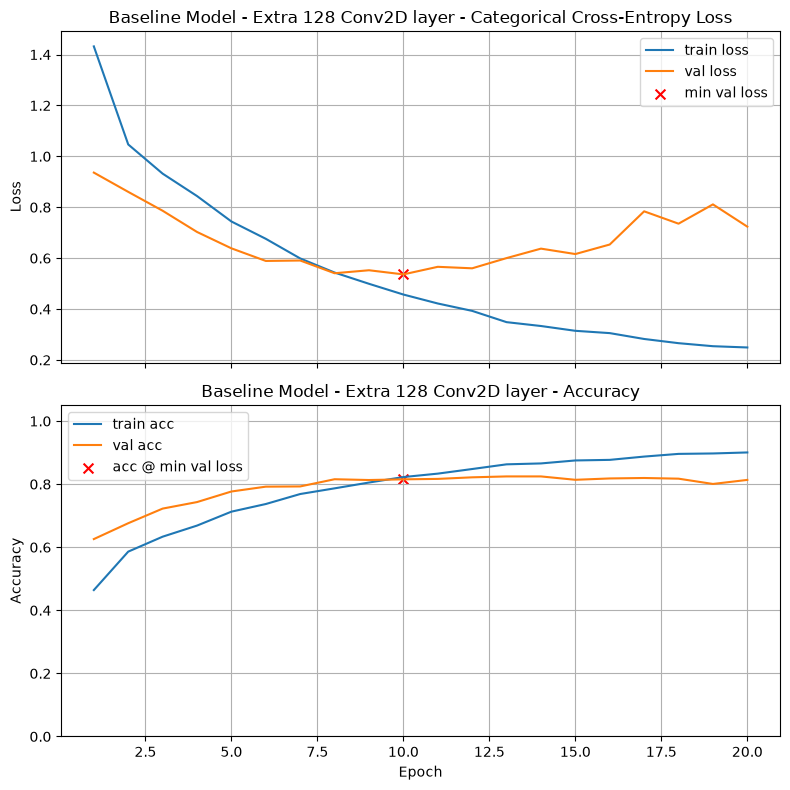

Final Training Loss:            0.2491
Final Training Accuracy:        0.9005
Final Validation Loss:          0.7238
Final Validation Accuracy:      0.8135
Minimum Validation Loss:        0.5362 (Epoch 10)
Validation Accuracy @ Min Loss: 0.8153

Test Loss: 0.5537
Test Accuracy: 0.8207

Validation-Test Gap (accuracy): 0.005403

Execution Time: 00:02:14


In [13]:
he = initializers.HeNormal()                                # best initializer for relu

model_baseline= models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu",kernel_initializer=he),            
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_baseline,title=f"Baseline Model - Extra 128 Conv2D layer")


### Problem 4

#### Tweak 1 - Increase Width of Dense layer to 128


Baseline Model - Double Dense Layer width (128)



I0000 00:00:1790115661.865773    3529 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_237784__.31
I0000 00:00:1790115669.809310    3531 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_237784__.31


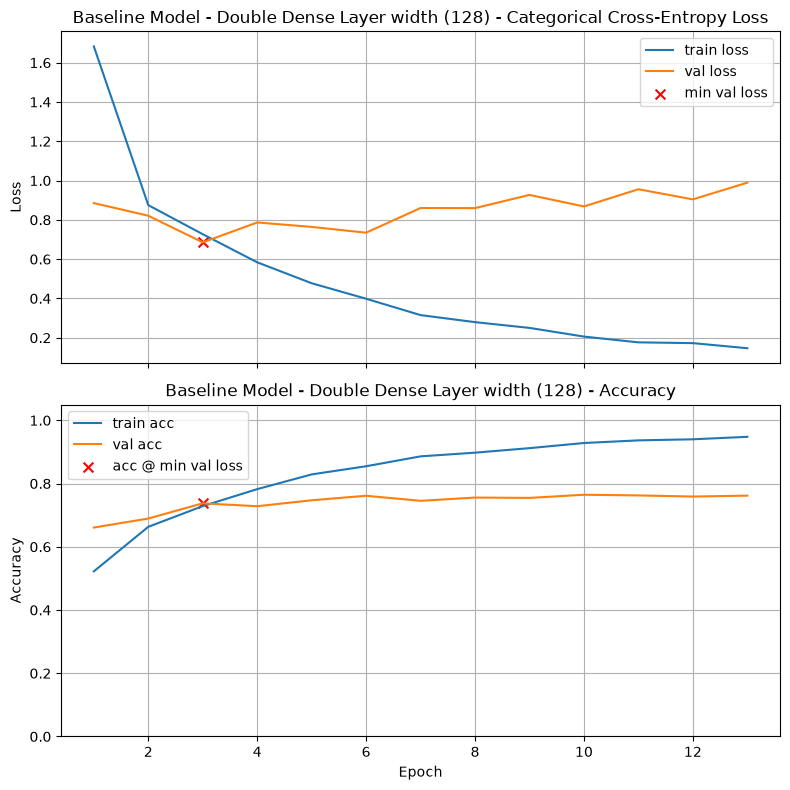

Final Training Loss:            0.1467
Final Training Accuracy:        0.9478
Final Validation Loss:          0.9894
Final Validation Accuracy:      0.7618
Minimum Validation Loss:        0.6855 (Epoch 3)
Validation Accuracy @ Min Loss: 0.7375

Test Loss: 0.7256
Test Accuracy: 0.7333

Validation-Test Gap (accuracy): 0.004184

Execution Time: 00:01:27


In [14]:
he = initializers.HeNormal()                                # best initializer for relu

model_baseline= models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Flatten(),
    Dense(128, activation="relu",kernel_initializer=he),            
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_baseline,title=f"Baseline Model - Double Dense Layer width (128)")


### Problem 5

#### Tweak 1 - Add L2 regularization to Dense Layer


Baseline Model - Dense Layer L2 regularization



I0000 00:00:1790115749.736620    3532 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_263348__.33
I0000 00:00:1790115756.587796    3529 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_263348__.33


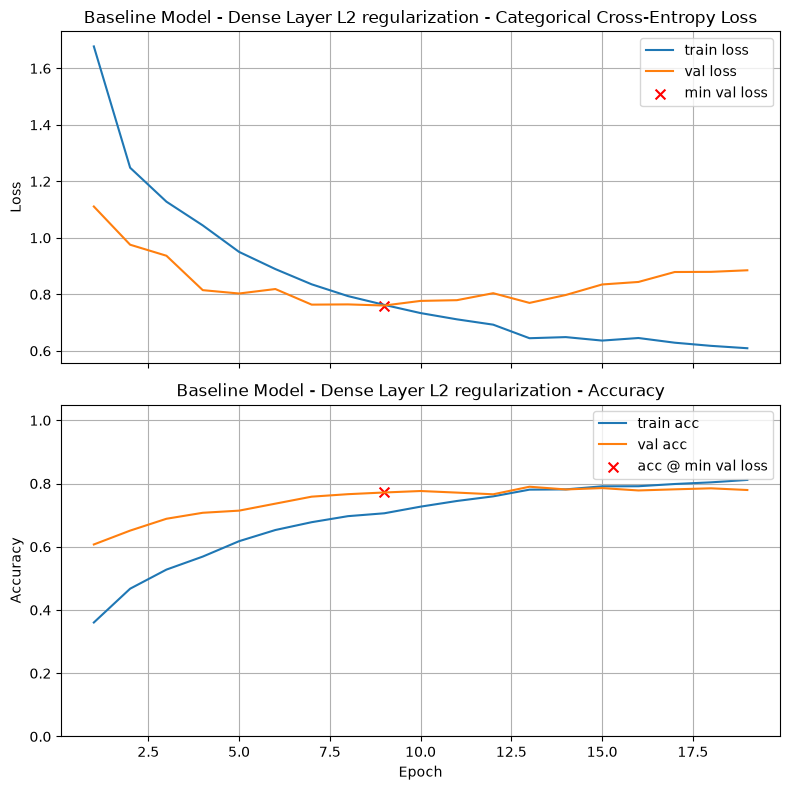

Final Training Loss:            0.6093
Final Training Accuracy:        0.8115
Final Validation Loss:          0.8852
Final Validation Accuracy:      0.7796
Minimum Validation Loss:        0.7605 (Epoch 9)
Validation Accuracy @ Min Loss: 0.7718

Test Loss: 0.7883
Test Accuracy: 0.7817

Validation-Test Gap (accuracy): 0.009912

Execution Time: 00:01:54


In [15]:
he = initializers.HeNormal()
l2reg = regularizers.l2(1e-4)   # set to None to disable or tweak the value
                                # best initializer for relu

model_baseline= models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu",kernel_initializer=he, kernel_regularizer=l2reg),            
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_baseline,title=f"Baseline Model - Dense Layer L2 regularization")


### Problem 6

#### Tweak 1. Decrease dropout rate to 0.3


Baseline Model - Dropout 0.3



I0000 00:00:1790115863.876730    3532 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_299624__.31
I0000 00:00:1790115870.705036    3529 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_299624__.31


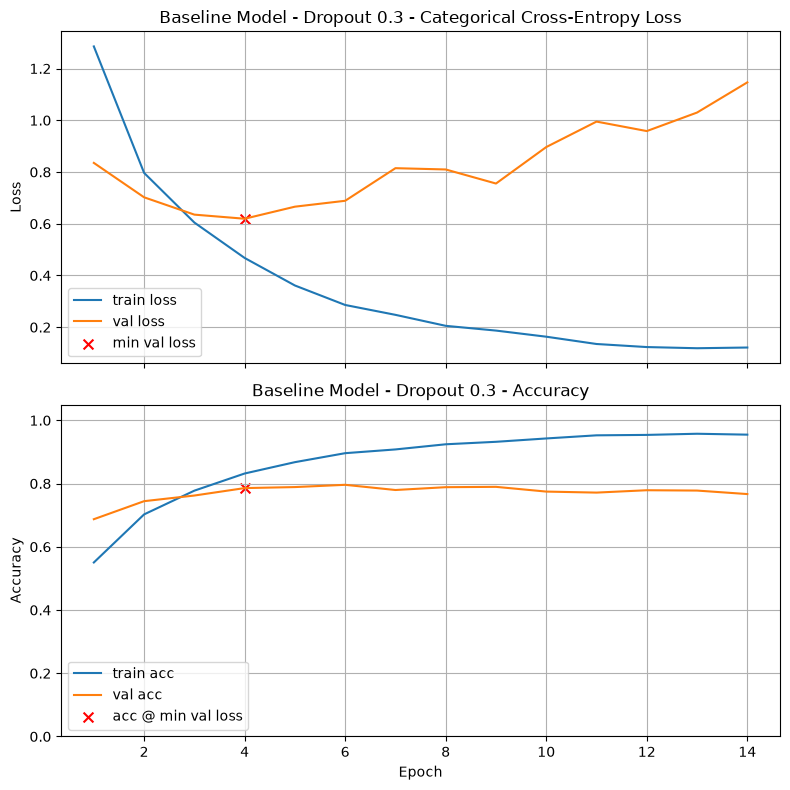

Final Training Loss:            0.1215
Final Training Accuracy:        0.9547
Final Validation Loss:          1.1465
Final Validation Accuracy:      0.7668
Minimum Validation Loss:        0.6194 (Epoch 4)
Validation Accuracy @ Min Loss: 0.7857

Test Loss: 0.6428
Test Accuracy: 0.7860

Validation-Test Gap (accuracy): 0.000337

Execution Time: 00:01:25


In [16]:
he = initializers.HeNormal()

model_baseline= models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu",kernel_initializer=he),            
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_baseline,title=f"Baseline Model - Dropout 0.3")


#### Tweak 2. Increase dropout rate to 0.7


Baseline Model - Dropout 0.7



I0000 00:00:1790115949.354278    3531 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_326918__.31
I0000 00:00:1790115956.254650    3532 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_326918__.31


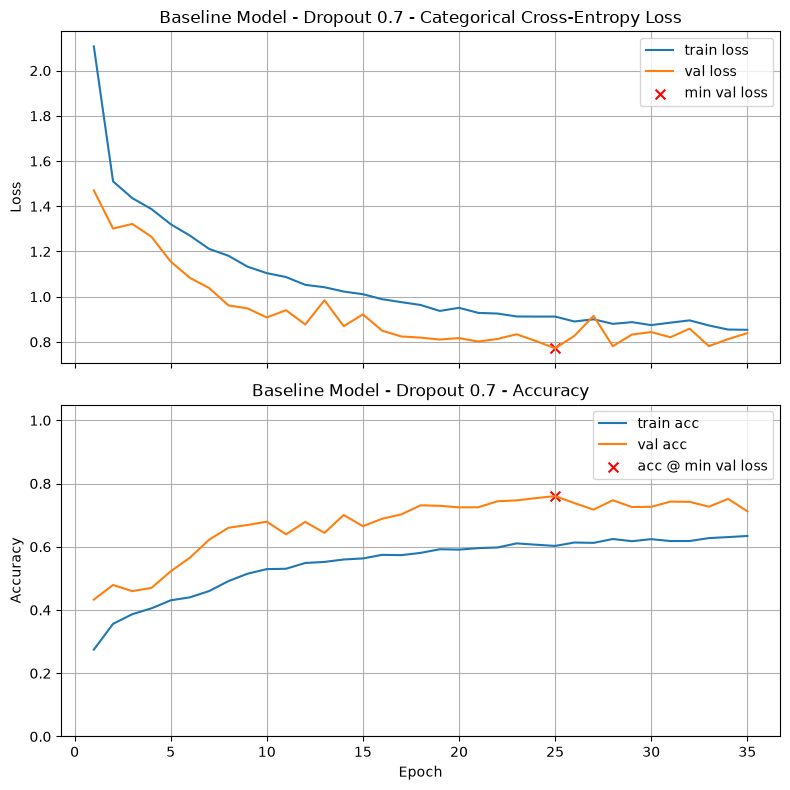

Final Training Loss:            0.8537
Final Training Accuracy:        0.6342
Final Validation Loss:          0.8391
Final Validation Accuracy:      0.7126
Minimum Validation Loss:        0.7722 (Epoch 25)
Validation Accuracy @ Min Loss: 0.7603

Test Loss: 0.8237
Test Accuracy: 0.7447

Validation-Test Gap (accuracy): 0.015676

Execution Time: 00:03:25


In [17]:
he = initializers.HeNormal()

model_baseline= models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu",kernel_initializer=he),            
    Dropout(0.7),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_baseline,title=f"Baseline Model - Dropout 0.7")


### Graded Questions

In [18]:
# Set a1a to the number of the individual "tweak" which provided the best validation accuracy at the epoch of minimum validation loss

a1a = 3             # Replace with integer 1 - 6; replace with -1 if you found no tweak which improved the results

In [19]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1a = {a1a}') 


a1a = 3


In [20]:
# Set a1b to the validation accuracy found by the choice specified in Question a1a. 

a1b = 0.8153             # Replace 0.0 with your answer

In [21]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1b = {a1b:.4f}') 

a1b = 0.8153


## Problem Two: Adding Batch Normalization

**Task:**
Take your best model from Problem One and add a `BatchNormalization()` layer immediately after each `Conv2D` layer. Batch normalization helps stabilize training and can improve convergence. 

**Next Steps:**

* Train the model with batch normalization included after each `Conv2D` layer. 
* Try at least one of tweaks from Problem 1 to see if you can improve your results in this new design. 
* Compare the results to your earlier experiments and answer the graded questions.

**Optional:**
Try more than one hyperparameter change alongside batch normalization and see how they interact.



### Best Model from Problem 1 - 32/64/128 Conv2D Stack with BatchNormalizaton


32/64/128 Conv2D layer stack with BatchNormalization



I0000 00:00:1790116156.021183    3529 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_393521__.56
I0000 00:00:1790116166.626491    3528 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_393521__.56


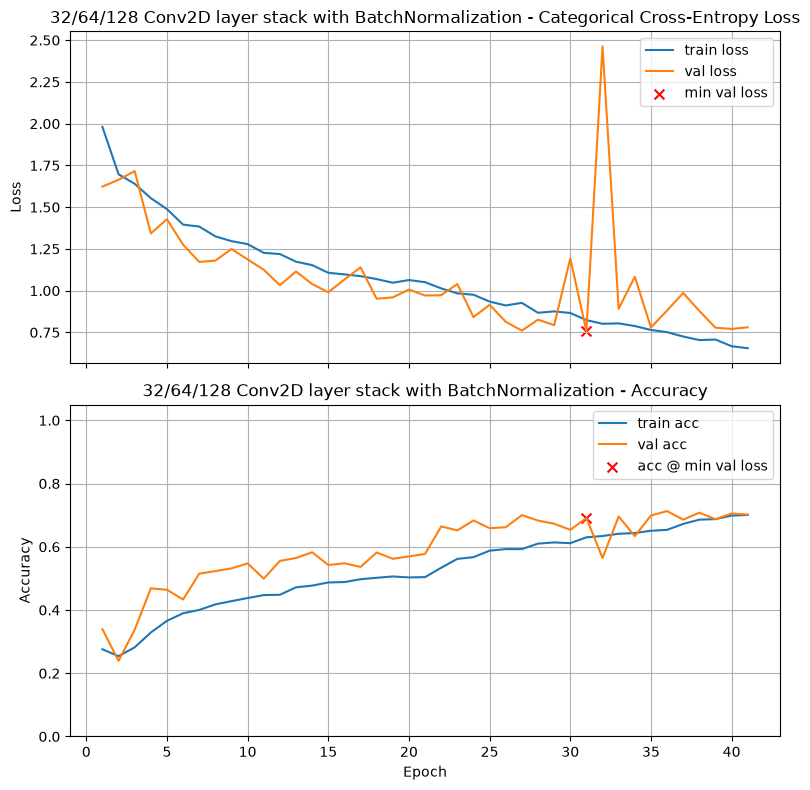

Final Training Loss:            0.6552
Final Training Accuracy:        0.7005
Final Validation Loss:          0.7805
Final Validation Accuracy:      0.7019
Minimum Validation Loss:        0.7583 (Epoch 31)
Validation Accuracy @ Min Loss: 0.6908

Test Loss: 0.8001
Test Accuracy: 0.6807

Validation-Test Gap (accuracy): 0.010132

Execution Time: 00:05:25


In [22]:
he = initializers.HeNormal()                                # best initializer for relu

model_baseline= models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu",kernel_initializer=he),            
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_baseline,title=f"32/64/128 Conv2D layer stack with BatchNormalization")


### Tweak 1 - Increase Width of Dense Layer


32/64/128 Conv2D layer stack with BatchNormalization and 128 Dense Layer



I0000 00:00:1790118075.216765    3530 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_516048__.56
I0000 00:00:1790118085.188143    3530 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_516048__.56


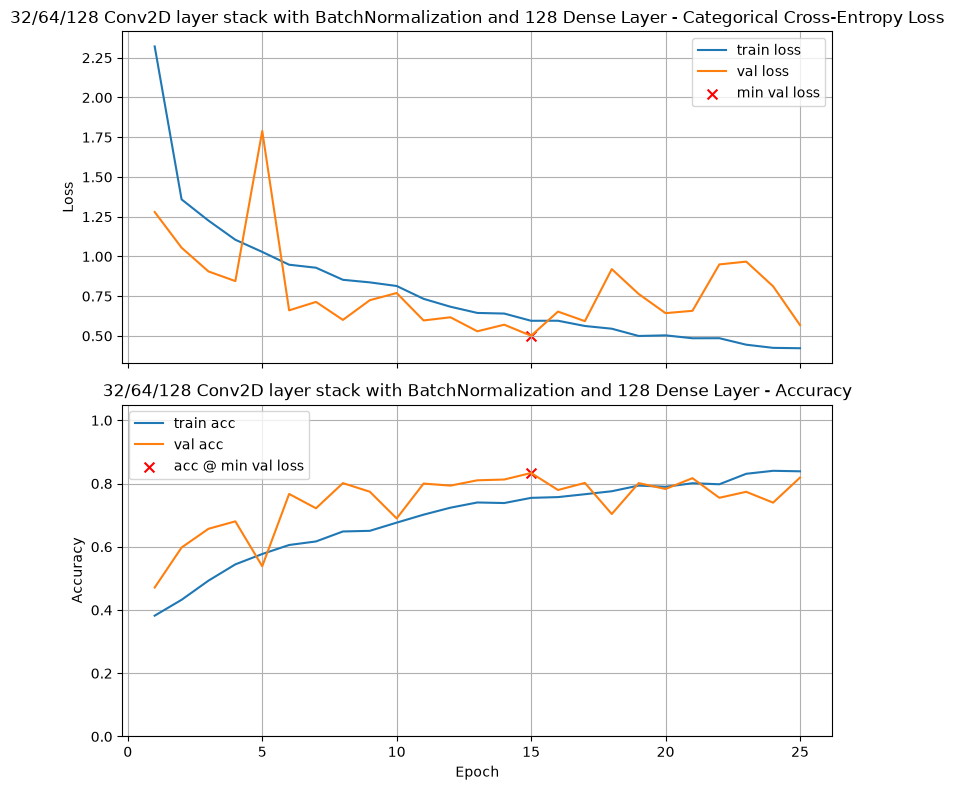

Final Training Loss:            0.4225
Final Training Accuracy:        0.8387
Final Validation Loss:          0.5682
Final Validation Accuracy:      0.8188
Minimum Validation Loss:        0.5010 (Epoch 15)
Validation Accuracy @ Min Loss: 0.8335

Test Loss: 0.5134
Test Accuracy: 0.8307

Validation-Test Gap (accuracy): 0.002786

Execution Time: 00:03:24


In [43]:
he = initializers.HeNormal()                                # best initializer for relu

model_baseline= models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Flatten(),
    Dense(128, activation="relu",kernel_initializer=he),            
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_baseline,title=f"32/64/128 Conv2D layer stack with BatchNormalization and 128 Dense Layer")


### Tweak 2 - Decrease Width of Conv2D layers


32/64/128 Conv2D layer stack with BatchNormalization and 128 Dense Layer



I0000 00:00:1790118279.990231    3530 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_565124__.56
I0000 00:00:1790118287.445902    3531 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_565124__.56


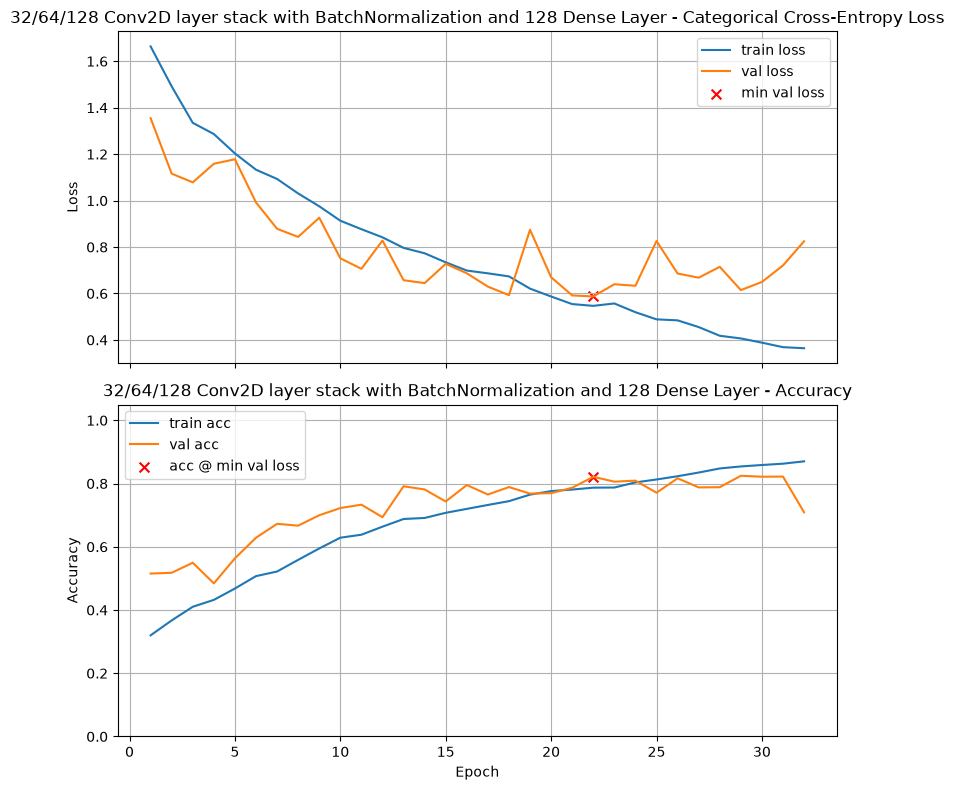

Final Training Loss:            0.3644
Final Training Accuracy:        0.8703
Final Validation Loss:          0.8248
Final Validation Accuracy:      0.7090
Minimum Validation Loss:        0.5872 (Epoch 22)
Validation Accuracy @ Min Loss: 0.8213

Test Loss: 0.6064
Test Accuracy: 0.8253

Validation-Test Gap (accuracy): 0.004007

Execution Time: 00:02:15


In [44]:
he = initializers.HeNormal()                                # best initializer for relu

model_baseline= models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(16, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu",kernel_initializer=he),            
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_baseline,title=f"32/64/128 Conv2D layer stack with BatchNormalization and 128 Dense Layer")

### Tweak 3 - lr: 5e-4 (0.0005)


32/64/128 Conv2D layer stack with BatchNormalization and 128 Dense Layer



I0000 00:00:1790118523.043553    3531 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_670544__.56
I0000 00:00:1790118532.569159    3530 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_670544__.56


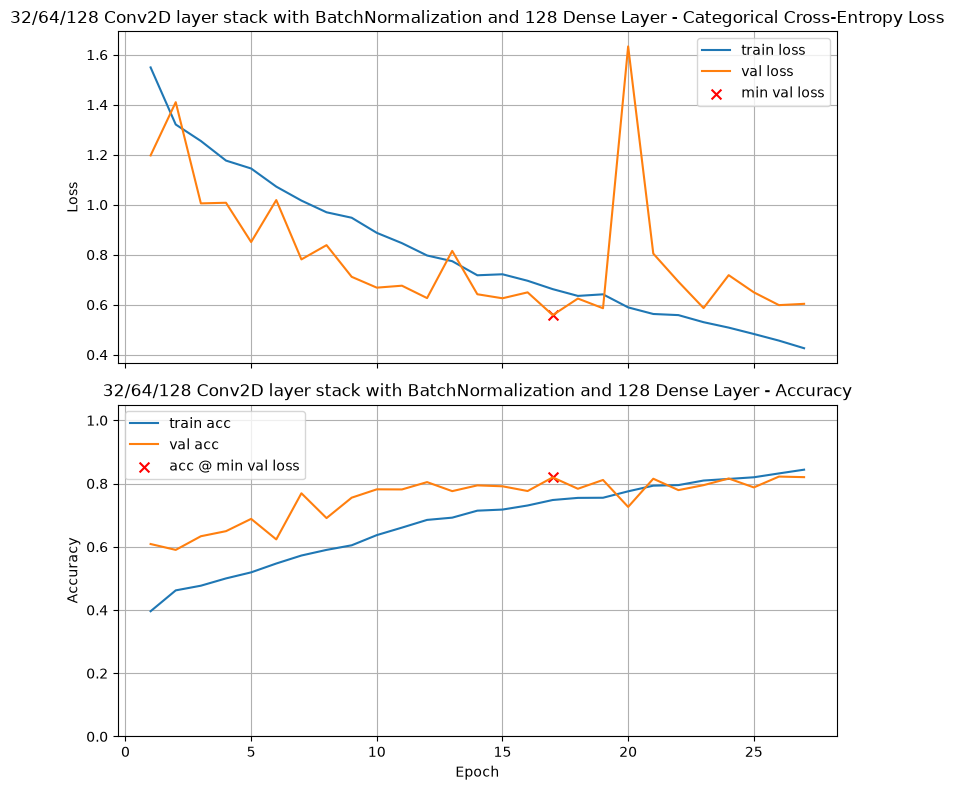

Final Training Loss:            0.4260
Final Training Accuracy:        0.8439
Final Validation Loss:          0.6035
Final Validation Accuracy:      0.8203
Minimum Validation Loss:        0.5585 (Epoch 17)
Validation Accuracy @ Min Loss: 0.8195

Test Loss: 0.6025
Test Accuracy: 0.8283

Validation-Test Gap (accuracy): 0.008790

Execution Time: 00:03:38


In [46]:
he = initializers.HeNormal()                                # best initializer for relu

model_baseline= models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu",kernel_initializer=he),            
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_baseline,title=f"32/64/128 Conv2D layer stack with BatchNormalization and LR 5e-4", lr_schedule=5e-4)

### Tweak 4 - L2 Reg


32/64/128 Conv2D layer stack with BatchNormalization and L2 Reg



/home/caleb/miniconda3/envs/tf_gpu/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1790118783.169806    3531 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_723258__.58
I0000 00:00:1790118792.732051    3530 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_723258__.58


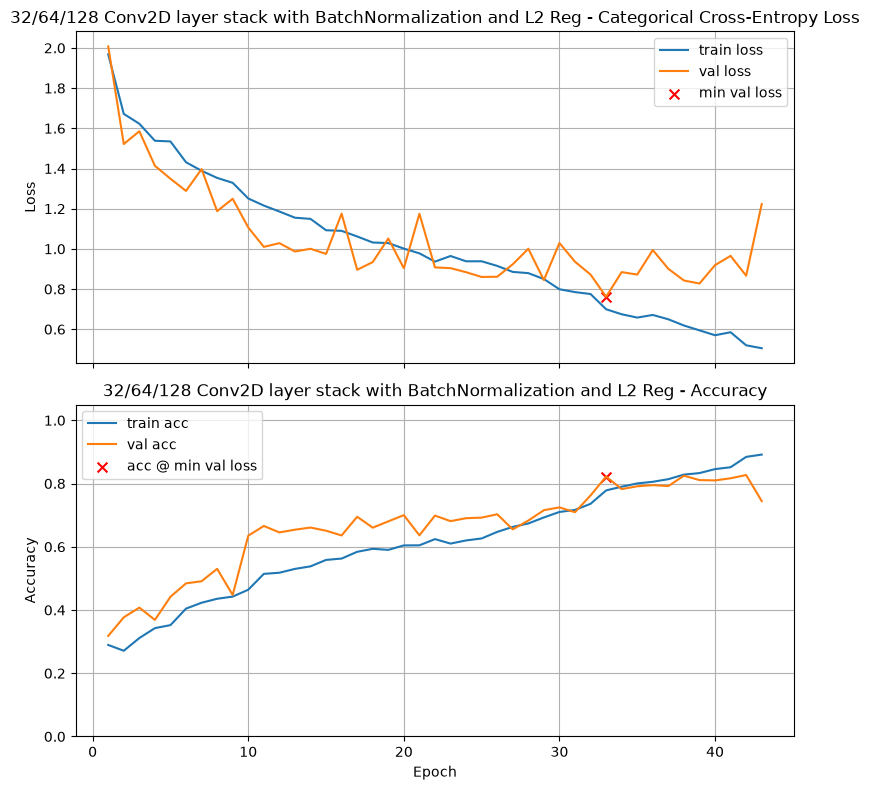

Final Training Loss:            0.5055
Final Training Accuracy:        0.8916
Final Validation Loss:          1.2230
Final Validation Accuracy:      0.7447
Minimum Validation Loss:        0.7618 (Epoch 33)
Validation Accuracy @ Min Loss: 0.8220

Test Loss: 0.8243
Test Accuracy: 0.8073

Validation-Test Gap (accuracy): 0.014707

Execution Time: 00:05:37


In [47]:
l2reg = regularizers.l2(1e-4)   # set to None to disable or tweak the value
                                # best initializer for relu

he = initializers.HeNormal()                                # best initializer for relu

model_baseline= models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu",kernel_initializer=he, kernel_regularizer=l2reg),            
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_baseline,title=f"32/64/128 Conv2D layer stack with BatchNormalization and L2 Reg")

### Tweak 5 - Double Conv2D Width


64/128/256 Conv2D layer stack with BatchNormalization



I0000 00:00:1790119120.209125    3529 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_804732__.56
I0000 00:00:1790119138.858345    3531 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_804732__.56


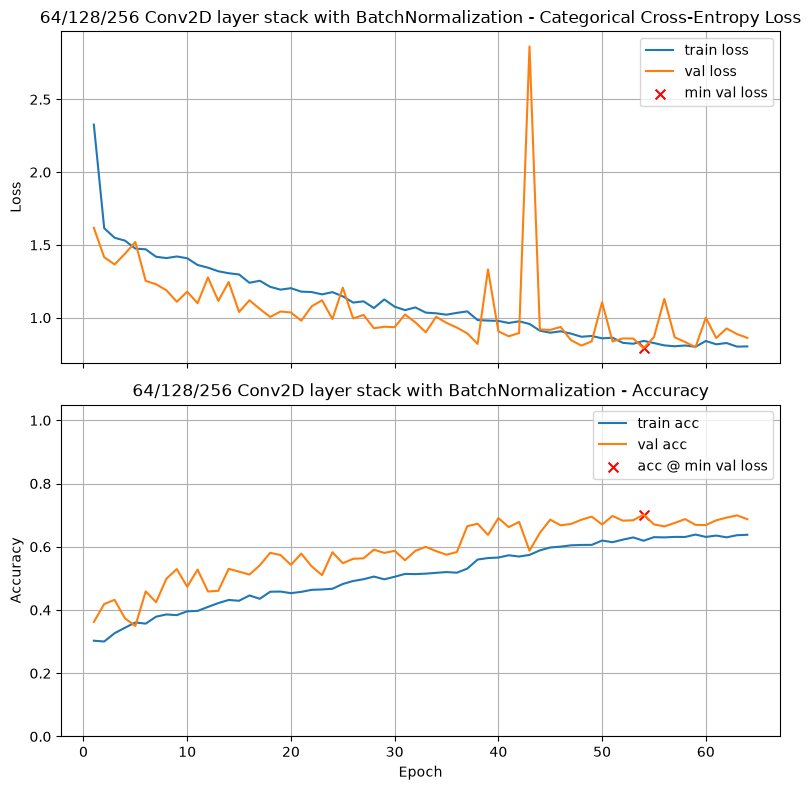

Final Training Loss:            0.8030
Final Training Accuracy:        0.6380
Final Validation Loss:          0.8615
Final Validation Accuracy:      0.6872
Minimum Validation Loss:        0.7906 (Epoch 54)
Validation Accuracy @ Min Loss: 0.7019

Test Loss: 0.8393
Test Accuracy: 0.6897

Validation-Test Gap (accuracy): 0.012188

Execution Time: 00:16:50


In [48]:
he = initializers.HeNormal() # best initializer for relu

model_baseline= models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(256, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu",kernel_initializer=he),            
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_baseline,title=f"64/128/256 Conv2D layer stack with BatchNormalization")

### Graded Questions

In [49]:
# Set a2a to the number of the individual "tweak" which provided the best validation accuracy at the epoch of minimum validation loss

a2a = 4             # Replace with integer 1 - 6; replace with -1 if you found no tweak which improved the results

In [50]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2a = {a2a}') 


a2a = 4


In [51]:
# Set a2b to the validation accuracy found by the choice specified in Question a2a (your best model for this problem) 

a2b = 0.8335             # Replace 0.0 with your answer

In [52]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2b = {a2b:.4f}') 

a2b = 0.8335


## Problem Three: Global Average Pooling

As we saw in this week's Coding Video, 
**Global Average Pooling** is a simple layer that replaces the `Flatten → Dense` part of a CNN (please review that part of the Coding Notebook, which contains a description of this important technique). 

In practice, swapping `Flatten` for `GlobalAveragePooling2D` often improves stability and validation performance — definitely worth considering!


**Task:**
Modify your best model from Problems 1 & 2 to use a `GlobalAveragePooling2D()` layer instead of a flatten-and-dense block. 

**Next Steps:**

* Replace the sequence between the last `Conv2D` and output layers, for example:

     
          MaxPooling2D((2, 2)),
          Flatten(),
          Dense(64, activation='relu', kernel_initializer=initializers.HeNormal()),
          Dropout(0.5),   

  with a single `GlobalAveragePooling2D()` layer.
* Train the model and observe how performance and training curves change.
* Try at least one of tweaks from Problem 1 to see if you can improve your results in this new design. 
* Compare results and answer the graded questions.

**Optional:**
Experiment with `GlobalMaxPooling2D()` as an alternative and compare its behavior to `GlobalAveragePooling2D()`.



In [27]:
# Your code here, add additional cells if you wish



### Graded Questions

In [28]:
# Set a3a to the number of the individual "tweak" which provided the best validation accuracy at the epoch of minimum validation loss

a3a = 0             # Replace with integer 1 - 6; replace with -1 if you found no tweak which improved the results

In [29]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3a = {a3a}') 


a3a = 0


In [30]:
# Set a3b to the validation accuracy found by the choice specified in Question a3a (your best model for this problem) 

a3b = 0.0             # Replace 0.0 with your answer

In [31]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3b = {a3b:.4f}') 

a3b = 0.0000


## Problem Four: ReduceLROnPlateau

`ReduceLROnPlateau` is a widely used learning rate scheduling technique. It monitors a validation metric (usually `val_loss`) and reduces the learning rate when progress stalls, allowing the model to refine training at a smaller step size. This is one of the most useful scheduling tools (along with the essential Early Stopping) to have in your toolbox.

**Task:**
Augment your best model found so far in Problems 1 - 3 with the `ReduceLROnPlateau` callback during training.

**Next Steps:**

* Add the callback parameter to `train_and_test`:

  ```python
  callbacks=[reduce_lr]
  ```

* Start with **`factor=0.5`** (monitor `val_loss`, `patience=2–3`, `cooldown=1`, `min_lr=1e-5` for Adam).
* **Practical playbook:**

  * If plateau persists after one reduction → try **`factor=0.3`**, then **`0.2`**.
  * If a reduction hurts validation noticeably → try **`factor=0.7–0.8`** or increase **`patience`**.
  * Leave **`cooldown=1`** unless you see too-frequent drops.
* Experiment with **`patience` = 3, 5, 8** and **`min_delta` = `1e-4` vs `1e-3`** to gauge sensitivity.
* Choose the configuration with the best validation results—or note that ReduceLROnPlateau didn’t help (rare!). 
* Answer the graded questions.



In [32]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Quantity to be monitored.
    factor=0.5,            # Factor by which the learning rate will be reduced.
                           # new_lr = lr * factor
    patience=3,            # Number of epochs with no improvement
                           # after which learning rate will be reduced.
    min_delta=1e-4,        # Threshold for measuring the new optimum,
                           # to only focus on significant changes.
    cooldown=1,            # Number of epochs to wait before resuming
                           # normal operation after lr has been reduced.
    min_lr=1e-5,           # Lower bound on the learning rate.
    verbose=0,             # 0: quiet, 1: update messages.
)

# Your code here, add more cells as needed

### Graded Questions

In [33]:
# Set a4a to the factor parameter which gave the best validation accuracy at the point of minimum validation loss

a4a = 0.0             # Replace with your best factor value, or set to -1 if reduce on plateau did not help at all

In [34]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4a = {a4a:.2f}') 

a4a = 0.00


In [35]:
# Set a4b to the validation accuracy found by the choice specified in Question a4a (your best model for this problem) 

a4b = 0.0             # Replace 0.0 with your answer

In [36]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4b = {a4b:.4f}') 

a4b = 0.0000


## Problem Five: A Very Deep CNN (VGG-16 Style)

 We will now experiment with the VGG-16 design introduced in the Coding Notebook and Video and see how it does on this dataset. For a beautiful description of the model and its significance, see [Explanation of VGG-16](https://viso.ai/deep-learning/vgg-very-deep-convolutional-networks/) :
        

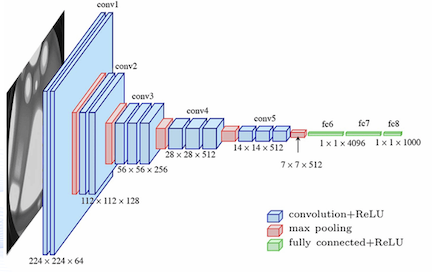


In this exercise you’ll **only vary the learning rate**. Don’t change any other hyperparameters. Your goal is to observe how LR affects convergence speed, stability, and final validation performance compared to your smaller baselines. This sets up next week’s **transfer learning** with pretrained models.

#### Starting point

* Optimizer: **Adam**
* **Recommended LR to start:** `1e-3`(Adam default)

#### What LR values to try (coarse → fine)

Try a short sweep like:

```
[1e-2, 3e-3, 1e-3, 3e-4, 1e-4, 3e-5, 1e-5]
```

Then, as time allows,  zoom in around the best.

#### How to judge “best”

* Primary: **best validation accuracy at epoch of lowest validation loss** 
* Secondary: **time-to-best** (fewer epochs to reach a strong val metric) and **curve shape** (smooth vs. noisy/oscillatory).

#### What symptoms mean

* **LR too high:** training loss spikes or oscillates; val metrics erratic, occasional NaNs/divergence.
* **LR too low:** very slow improvement; long flat regions; never reaches your smaller models’ performance.


**Tip:** Keep LR **constant** during each run (don’t schedule) so you isolate its effect. 




VGG-style Large



/home/caleb/miniconda3/envs/tf_gpu/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1790116482.233031    3531 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_472260__.50
I0000 00:00:1790116535.145310    3532 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_472260__.50


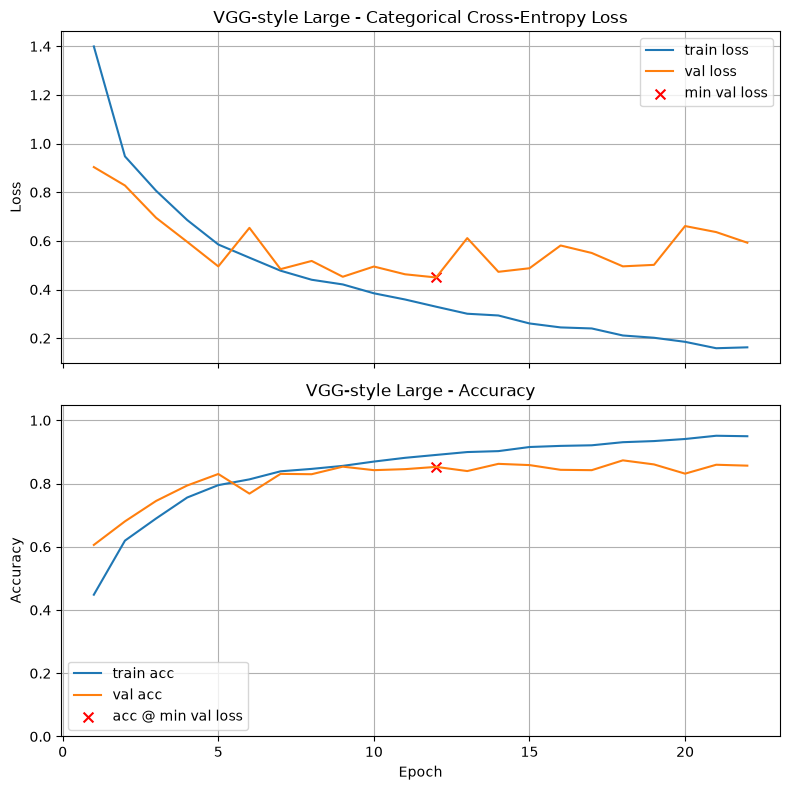

Final Training Loss:            0.1624
Final Training Accuracy:        0.9497
Final Validation Loss:          0.5925
Final Validation Accuracy:      0.8566
Minimum Validation Loss:        0.4496 (Epoch 12)
Validation Accuracy @ Min Loss: 0.8527

Test Loss: 0.4387
Test Accuracy: 0.8557

Validation-Test Gap (accuracy): 0.002956

Execution Time: 00:15:41


In [37]:
he = initializers.HeNormal()
l2reg = regularizers.l2(1e-4)   # set to None to disable or tweak the value

model_vgg_16 = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    # Block 1
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 4 (NO MaxPool here -> leaves 3×3×512)
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),

    # Global pooling meaningfully summarizes the 3×3 map
    layers.GlobalAveragePooling2D(),   # swap to GlobalMaxPooling2D() to compare

    # Compact head
    layers.Dense(256, activation='relu', kernel_initializer=he,
                 kernel_regularizer=l2reg),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

# Uncomment the next line to run

train_and_test(model_vgg_16,lr_schedule=1e-3,title="VGG-style Large")


### Graded Questions

In [38]:
# Set a5a to the learning rate which gave the best validation accuracy at the point of minimum validation loss

a5a = 0.0             # Replace with your best learning rate

In [39]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5a = {a5a:.8f}') 

a5a = 0.00000000


In [40]:
# Set a5b to the validation accuracy found by the choice specified in Question a5a (your best model for this problem) 

a5b = 0.0              # Replace 0.0 with your answer           

In [41]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5b = {a5b:.4f}') 

a5b = 0.0000


## All Results

This will print out the results from all experiments, with titles as keys. I use this all the time to keep track of experiments!

In [42]:
print_results()

VGG-style Large                         	0.8527	12
Baseline Model - Extra 128 Conv2D layer 	0.8153	10
Baseline Model                          	0.7978	6
Baseline Model - double Conv2D width (64 and 128)	0.7896	11
Baseline Model - lr 5e-4                	0.7882	13
Baseline Model - Dropout 0.3            	0.7857	4
Baseline Model - Dense Layer L2 regularization	0.7718	9
Baseline Model - Halve Conv2D width (16 and 32)	0.7611	9
Baseline Model - Dropout 0.7            	0.7603	25
Baseline Model - Double Dense Layer width (128)	0.7375	3
32/64/128 Conv2D layer stack with BatchNormalization	0.6908	31
Baseline Model - lr 1e-4                	0.1790	25
